In [1]:
import json
import os
import re
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import pandas as pd
import polars as pl

QF_DISPLAY = {
    "body": "Original Query",
    "synonyms": "+ Gene Synonyms",
    "long": "+ Gene Synonyms & Products",
}

RERANK_DISPLAY = {
    "body": "Rerank (Original Query)",
    "synonyms": "Rerank (+ Gene Synonyms)",
    "long": "Rerank (+ Gene Synonyms & Products)",
    "hybrid": "Retrieval Fusion (long)",
}

## Query-field sweep: statistical comparison (recall 200–1000)

We compare retrieval profiles (e.g. hybrid combo bm25_qf × dense_qf) using **mean recall over K ∈ {200, 300, 400, 500, 1000}** so the choice of operating point (e.g. rerank cutoff) does not dominate. Data from `scripts/private_scripts/hpc_scripts/query_expansion/combine_query_field_sweep_results.py` (combined sweep metrics). Stats: mean ± std across batches (train/test), rank, and optional paired test of best vs others.

In [2]:
# Two benchmarks (7d / 7e): sweep under `workflow_query_field_sweep_no_rm3_{tag}/query_field_sweep/`;
# rerank under `workflow_fixed_long_rerank_sweep_{tag}/fixed_long_rerank_sweep/` (see Vega configs).
root = Path(os.environ.get("DICTYCITE_ROOT", "../"))

BENCHMARK_CONFIGS = [
    {
        "tag": "7d",
        "sweep_dir": Path("output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7d/query_field_sweep"),
        "gold_jsonl": Path("output/dicty_gold_build/7d_dicty_gold_query_expansion_benchmark.jsonl"),
        "rerank_dir": Path("output/workflow_baseline_full_sweep/workflow_fixed_long_rerank_sweep_7d/fixed_long_rerank_sweep"),
        "run_token": "7d_dicty_gold_query_expansion_benchmark",
    },
    {
        "tag": "7e",
        "sweep_dir": Path("output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7e/query_field_sweep"),
        "gold_jsonl": Path("output/dicty_gold_build/7e_dicty_gold_query_expansion_benchmark.jsonl"),
        "rerank_dir": Path("output/workflow_baseline_full_sweep/workflow_fixed_long_rerank_sweep_7e/fixed_long_rerank_sweep"),
        "run_token": "7e_dicty_gold_query_expansion_benchmark",
    },
]


def _resolve_sweep_csv(cfg: dict) -> Path | None:
    for base in (root, Path("../")):
        d = base / cfg["sweep_dir"]
        for name in ("combined_sweep_metrics.csv", "combined_sweep_metrics_wide.csv"):
            p = d / name
            if p.is_file():
                return p
    return None

Recall (mean over K in {200..1000}), mean ± std across batches:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""HYBRID (+ Gene Synonyms & Prod…",0.967111,0.001786,1,1.954904,1
"""HYBRID (+ Gene Synonyms, + Gen…",0.963938,0.003936,1,1.951845,2
"""HYBRID (+ Gene Synonyms & Prod…",0.962951,0.002222,1,1.94928,3
"""HYBRID (+ Gene Synonyms & Prod…",0.962611,0.001515,1,1.946319,4
"""HYBRID (Original Query, + Gene…",0.958383,0.004801,1,1.943556,5
…,…,…,…,…,…
"""BM25 (Original Query, + Gene S…",0.874038,null,1,1.798697,23
"""BM25 (Original Query, + Gene S…",0.874038,null,1,1.798697,24
"""DENSE (+ Gene Synonyms, Origin…",0.867644,null,1,1.792481,25



Top profiles by stage (ranked by score_r500_r1000 when available, else mean_recall):


BM25 profiles:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""BM25 (+ Gene Synonyms & Produc…",0.938869,null,1,1.902309,12
"""BM25 (+ Gene Synonyms & Produc…",0.938869,null,1,1.902309,13
"""BM25 (+ Gene Synonyms & Produc…",0.938869,null,1,1.902309,14
"""BM25 (+ Gene Synonyms, Origina…",0.911042,null,1,1.865009,19
"""BM25 (+ Gene Synonyms, + Gene …",0.911042,null,1,1.865009,20



DENSE profiles:



...

query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.938869,1.902309
"""+ Gene Synonyms""",0.911042,1.865009
"""Original Query""",0.874038,1.798697



DENSE – 7d_dicty_gold_query_expansion_benchmark:


query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.943191,1.916815
"""+ Gene Synonyms""",0.919242,1.881587
"""Original Query""",0.867644,1.792481


MRR@K summary (7d benchmark):


7D BENCHMARK:


method,MRR@1,MRR@5,MRR@10,MRR@20,MRR@50,MRR@100,MRR@200
str,f64,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms)""",0.5382,0.6137,0.6229,0.6256,0.6278,0.6282,0.6283
"""Rerank (+ Gene Synonyms & Prod…",0.5275,0.6132,0.6224,0.6242,0.6261,0.6267,0.6269
"""Retrieval Fusion (long)""",0.508,0.6076,0.6185,0.6225,0.6232,0.6235,0.6237
"""Rerank (Original Query)""",0.4813,0.5687,0.5761,0.5795,0.5814,0.5819,0.5821


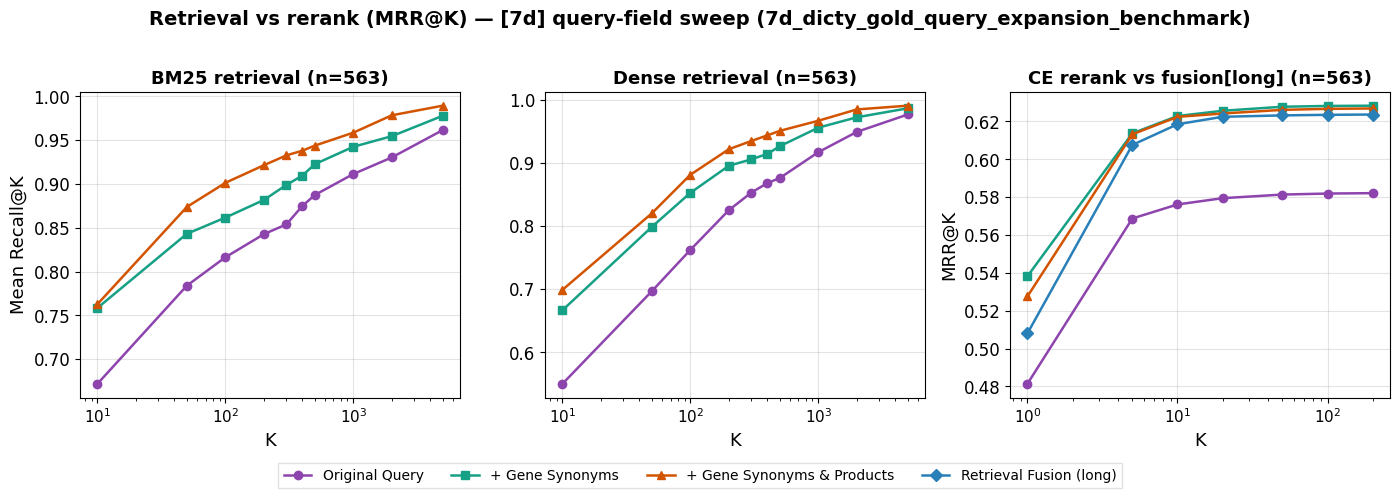

[7d] Saved 1×3 retrieval (+ rerank) figures under ../output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7d/query_field_sweep/figures
Recall (mean over K in {200..1000}), mean ± std across batches:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""HYBRID (+ Gene Synonyms, + Gen…",0.996388,0.000756,1,1.997653,1
"""HYBRID (+ Gene Synonyms & Prod…",0.995853,0.000809,1,1.99687,2
"""HYBRID (+ Gene Synonyms & Prod…",0.99464,0.001679,1,1.996479,3
"""HYBRID (+ Gene Synonyms & Prod…",0.99511,0.001447,1,1.996479,4
"""HYBRID (Original Query, + Gene…",0.990858,0.001048,1,1.989828,5
…,…,…,…,…,…
"""BM25 (Original Query, + Gene S…",0.948279,null,1,1.921362,23
"""BM25 (Original Query, + Gene S…",0.948279,null,1,1.921362,24
"""DENSE (+ Gene Synonyms, Origin…",0.9277,null,1,1.892019,25



Top profiles by stage (ranked by score_r500_r1000 when available, else mean_recall):


BM25 profiles:



profile,mean_recall,std_recall,n_batches,score_r500_r1000,rank
str,f64,f64,i64,f64,i64
"""BM25 (+ Gene Synonyms & Produc…",0.98662,null,1,1.983568,7
"""BM25 (+ Gene Synonyms & Produc…",0.98662,null,1,1.983568,8
"""BM25 (+ Gene Synonyms & Produc…",0.98662,null,1,1.983568,9
"""BM25 (+ Gene Synonyms, Origina…",0.974413,null,1,1.960094,16
"""BM25 (+ Gene Synonyms, + Gene …",0.974413,null,1,1.960094,17



DENSE profiles:



...

query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.98662,1.983568
"""+ Gene Synonyms""",0.974413,1.960094
"""Original Query""",0.948279,1.921362



DENSE – 7e_dicty_gold_query_expansion_benchmark:


query_field,mean_recall,score_r500_r1000
str,f64,f64
"""+ Gene Synonyms & Products""",0.974491,1.967136
"""+ Gene Synonyms""",0.963146,1.944836
"""Original Query""",0.9277,1.892019


MRR@K summary (7e benchmark):


7E BENCHMARK:


method,MRR@1,MRR@5,MRR@10,MRR@20,MRR@50,MRR@100,MRR@200
str,f64,f64,f64,f64,f64,f64,f64
"""Rerank (+ Gene Synonyms)""",0.6315,0.7075,0.715,0.7166,0.7182,0.7184,0.7185
"""Rerank (+ Gene Synonyms & Prod…",0.6221,0.7051,0.7131,0.7147,0.7158,0.7162,0.7163
"""Retrieval Fusion (long)""",0.5915,0.6902,0.6991,0.7021,0.7028,0.703,0.7031
"""Rerank (Original Query)""",0.5681,0.6658,0.6707,0.6738,0.6752,0.6756,0.6757


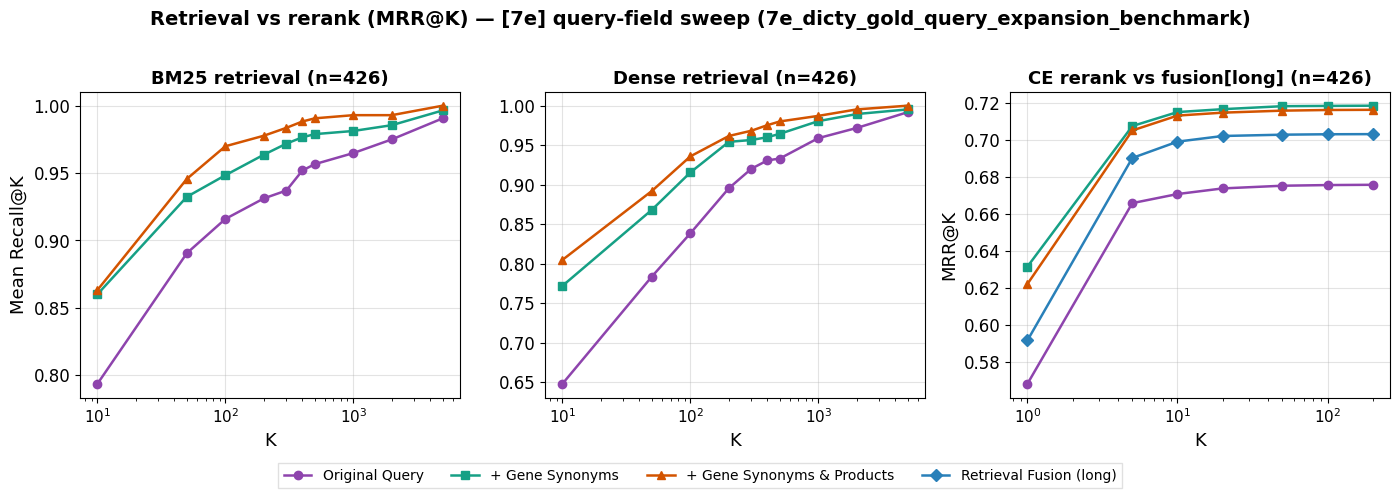

[7e] Saved 1×3 retrieval (+ rerank) figures under ../output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7e/query_field_sweep/figures


In [3]:
# Path to combined sweep metrics (from combine_query_field_sweep_results.py)

K_RANGE = [200, 300, 400, 500, 1000]  # recall@K range for "operating region" metric
MEANR_COLS = [f"MeanR@{k}" for k in K_RANGE]

for cfg in BENCHMARK_CONFIGS:
    SWEEP_CSV = _resolve_sweep_csv(cfg)
    if SWEEP_CSV is None:
        print(
            f"[{cfg['tag']}] No combined_sweep_metrics*.csv under {cfg['sweep_dir']}. "
            "Run combine_query_field_sweep_results.py for this sweep; skipping benchmark."
        )
        continue

    df = pd.read_csv(SWEEP_CSV)

    # If we loaded the wide-format combined_sweep_metrics_wide.csv, reshape to long format
    # expected by the rest of this notebook (stage + bm25_query_field + dense_query_field + MeanR@K).
    if SWEEP_CSV.name.endswith("combined_sweep_metrics_wide.csv"):
        if "query_field" not in df.columns:
            raise ValueError(f"Expected 'query_field' column in wide sweep metrics, got: {list(df.columns)}")

        rows_long = []
        methods = ["bm25", "dense", "hybrid"]
        roles = ["train", "test"]
        for _, row in df.iterrows():
            qf = str(row["query_field"]).strip()
            for method in methods:
                for role in roles:
                    rec_vals = {}
                    for k in K_RANGE:
                        wide_col = f"{role}_{method}_MeanR@{k}"
                        if wide_col in df.columns:
                            rec_vals[f"MeanR@{k}"] = float(row[wide_col])
                    if not rec_vals:
                        continue
                    rows_long.append({
                        "stage": method,
                        "bm25_query_field": qf,
                        "dense_query_field": qf,
                        "batch": role,
                        **rec_vals,
                    })
        if not rows_long:
            raise ValueError("No MeanR@K columns found in wide sweep metrics; cannot build long-format table.")
        df = pd.DataFrame(rows_long)

    # Ensure we have the recall columns (hybrid/bm25/dense may have different column sets)
    available = [c for c in MEANR_COLS if c in df.columns]
    if not available:
        raise ValueError(f"None of {MEANR_COLS} found in {SWEEP_CSV}. Columns: {list(df.columns)}")

    # Mean recall over K in [200, 300, 400, 500, 1000] per (profile, batch). Profile = stage + query fields.
    df["batch"] = df["batch"].astype(str).str.strip()
    if "stage" in df.columns:
        df["stage"] = df["stage"].astype(str).str.strip()
    if "bm25_query_field" in df.columns and "dense_query_field" in df.columns:
        df["bm25_query_field"] = df["bm25_query_field"].astype(str).str.strip()
        df["dense_query_field"] = df["dense_query_field"].astype(str).str.strip()
        df["bm25_qf_display"] = df["bm25_query_field"].map(QF_DISPLAY).fillna(df["bm25_query_field"])
        df["dense_qf_display"] = df["dense_query_field"].map(QF_DISPLAY).fillna(df["dense_query_field"])
        df["profile"] = df["stage"].str.upper() + " (" + df["bm25_qf_display"] + ", " + df["dense_qf_display"] + ")"
    else:
        df["profile"] = df.get("stage", df.get("method", "unknown"))

    # Operating-region mean recall across K
    df["mean_recall_200_1000"] = df[available].mean(axis=1)

    # Simple scoring profile: MeanR@500 + MeanR@1000 (when available)
    score_cols = [c for c in ["MeanR@500", "MeanR@1000"] if c in df.columns]
    if score_cols:
        df["score_r500_r1000"] = df[score_cols].sum(axis=1)

    # Per-profile summary: mean/std across batches
    agg_dict = {
        "mean_recall_200_1000": ["mean", "std"],
        "batch": ["nunique"],
    }
    if "score_r500_r1000" in df.columns:
        agg_dict["score_r500_r1000"] = ["mean"]

    summary = df.groupby("profile").agg(agg_dict)
    summary.columns = [
        "mean_recall" if c == ("mean_recall_200_1000", "mean") else
        "std_recall" if c == ("mean_recall_200_1000", "std") else
        "n_batches" if c == ("batch", "nunique") else
        "score_r500_r1000" if c == ("score_r500_r1000", "mean") else "_".join(map(str, c))
        for c in summary.columns
    ]
    summary = summary.reset_index()

    # Rank by score profile when available, otherwise by mean_recall
    if "score_r500_r1000" in summary.columns:
        summary = summary.sort_values("score_r500_r1000", ascending=False).reset_index(drop=True)
    else:
        summary = summary.sort_values("mean_recall", ascending=False).reset_index(drop=True)
    summary["rank"] = range(1, len(summary) + 1)

    print("Recall (mean over K in {200..1000}), mean ± std across batches:\n")
    display(pl.from_pandas(summary))

    # Per-stage top profiles for quick inspection (BM25 and Dense)
    print("\nTop profiles by stage (ranked by score_r500_r1000 when available, else mean_recall):\n")

    for stage in ["bm25", "dense"]:
        # Filter profiles belonging to this stage (profile starts with STAGE in upper-case)
        stage_profiles = summary[summary["profile"].str.upper().str.startswith(stage.upper())]
        if stage_profiles.empty:
            continue
        print(f"\n{stage.upper()} profiles:\n")
        display(pl.from_pandas(stage_profiles.head(5)))


    # Compact per-stage summary: for each batch (train/test), three scores per query-field
    # Uses score profile: MeanR@500 + MeanR@1000 when available.

    batches = sorted(df["batch"].astype(str).str.strip().unique().tolist())

    print("Per-stage summary by batch (BM25 and DENSE):\n")

    for stage in ["bm25", "dense"]:
        stage_df = df[df["stage"] == stage].copy()
        if stage_df.empty:
            continue

        # Stage-specific query field
        if stage == "bm25":
            stage_df["qf"] = stage_df["bm25_query_field"].astype(str).str.strip()
        else:
            stage_df["qf"] = stage_df["dense_query_field"].astype(str).str.strip()
        stage_df["qf_display"] = stage_df["qf"].map(QF_DISPLAY).fillna(stage_df["qf"])

        # Score profile: MeanR@500 + MeanR@1000 (when available)
        score_cols = [c for c in ["MeanR@500", "MeanR@1000"] if c in stage_df.columns]
        if score_cols:
            stage_df["score_r500_r1000"] = stage_df[score_cols].sum(axis=1)

        stage_df["batch"] = stage_df["batch"].astype(str).str.strip()

        for batch in batches:
            sub = stage_df[stage_df["batch"] == batch]
            if sub.empty:
                continue

            agg = {
                "mean_recall_200_1000": "mean",
            }
            if "score_r500_r1000" in sub.columns:
                agg["score_r500_r1000"] = "mean"

            summary_stage = (
                sub.groupby("qf_display").agg(agg).reset_index()
            )

            # Rename columns for display
            cols = {"qf_display": "query_field", "mean_recall_200_1000": "mean_recall"}
            summary_stage = summary_stage.rename(columns=cols)

            # Sort by score if present, otherwise by mean_recall
            if "score_r500_r1000" in summary_stage.columns:
                summary_stage = summary_stage.sort_values("score_r500_r1000", ascending=False)
            else:
                summary_stage = summary_stage.sort_values("mean_recall", ascending=False)

            print(f"\n{stage.upper()} – {batch}:")
            display(pl.from_pandas(summary_stage))

    # Plot recall curves per batch: BM25 | Dense in 1×2 panels. X-axis is log-scaled (K).
    # n in subtitles only when metrics.csv / combined CSV supplies a consistent `n_queries`.

    def _n_queries_if_known(subset: pd.DataFrame, batch: str) -> int | None:
        """Return evaluation query count only from `n_queries` when present and unique per batch."""
        sub = subset[subset["batch"].astype(str).str.strip() == str(batch).strip()]
        if sub.empty or "n_queries" not in sub.columns:
            return None
        n = pd.to_numeric(sub["n_queries"], errors="coerce").dropna()
        if n.empty:
            return None
        uniq = n.unique()
        if len(uniq) != 1:
            return None
        return int(uniq[0])


    # Recall columns + K ordering
    recall_cols = sorted(
        [c for c in df.columns if c.startswith("MeanR@")],
        key=lambda c: int(c.split("@")[1]),
    )
    if not recall_cols:
        raise ValueError(f"No MeanR@K columns found in sweep metrics: {list(df.columns)}")
    ks = [int(c.split("@")[1]) for c in recall_cols]

    plot_df = df.copy()
    plot_df["batch"] = plot_df["batch"].astype(str).str.strip()
    plot_df["stage"] = plot_df["stage"].astype(str).str.strip()
    plot_df["combo"] = plot_df.get("combo", "").astype(str).str.strip()
    plot_df["bm25_qf"] = plot_df["bm25_query_field"].astype(str).str.strip()
    plot_df["dense_qf"] = plot_df["dense_query_field"].astype(str).str.strip()

    plot_df["bm25_qf_disp"] = plot_df["bm25_qf"].map(QF_DISPLAY).fillna(plot_df["bm25_qf"])
    plot_df["dense_qf_disp"] = plot_df["dense_qf"].map(QF_DISPLAY).fillna(plot_df["dense_qf"])

    batches = plot_df["batch"].unique().tolist()
    qf_order = ["body", "synonyms", "long"]

    # Distinct from notebooks/report.py tab-blues/oranges/greens
    QF_COLORS = {"body": "#8e44ad", "synonyms": "#16a085", "long": "#d35400"}
    QF_MARKERS = {"body": "o", "synonyms": "s", "long": "^"}

    figures_dir = root / cfg["sweep_dir"] / "figures"
    figures_dir.mkdir(parents=True, exist_ok=True)

    _rc_plot = {
        "figure.figsize": (13.5, 4.8),
        "axes.titlesize": 14,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 12,
    }

    # --- Rerank MRR@K: load before combined figure ---
    RERANK_SWEEP_DIR = root / cfg["rerank_dir"]

    RERANK_DIRS = {
        "body": RERANK_SWEEP_DIR / "rerank_body",
        "synonyms": RERANK_SWEEP_DIR / "rerank_synonyms",
        "long": RERANK_SWEEP_DIR / "rerank_long",
        "hybrid": RERANK_SWEEP_DIR / "retrieval" / "fusion",
    }

    KS_MAP = [1, 5, 10, 20, 50, 100, 200]


    def load_gold_jsonl(path: Path) -> dict:
        """Load gold from JSONL: qid -> list of relevant docnos (PMIDs as strings)."""
        gold = {}
        with open(path, encoding="utf-8") as f:
            for line in f:
                line = line.strip()
                if not line:
                    continue
                q = json.loads(line)
                qid = str(q.get("query_id", q.get("id", "")))
                if not qid:
                    continue
                pmids = []
                for doc in q.get("documents", []):
                    if isinstance(doc, str) and doc.startswith("http"):
                        pmids.append(doc.split("/")[-1])
                    elif doc:
                        pmids.append(str(doc))
                for d in q.get("docs", []):
                    if isinstance(d, dict) and d.get("pmid"):
                        pmids.append(str(d["pmid"]))
                gold[qid] = list(set(pmids))
        return gold


    def load_run(path):
        """Load run TSV: qid -> ranked list of docnos.

        CE rerank TSVs are typically ``qid, docno, rank, score``; retrieval fusion from
        ``fuse_retrieval.runmap_to_tsv`` is ``qid, rank, docno, score``. Resolve columns
        by name when a header row is present. Treat ``\\ufeffqid`` as ``qid`` so UTF-8 BOM
        does not force the no-header fallback (where ``docno_idx=1`` would read *rank* as
        docno for fusion files and collapse fusion MRR).
        """
        run = {}
        header = None

        def _header_indices(h: list[str]) -> tuple[int, int]:
            low = [p.lstrip("\ufeff").lower() for p in h]
            qid_idx = low.index("qid") if "qid" in low else 0
            for key in ("docno", "docid", "doc"):
                if key in low:
                    return qid_idx, low.index(key)
            return qid_idx, 1

        with open(path, encoding="utf-8") as f:
            for line in f:
                parts = line.strip().split("\t")
                if not parts:
                    continue
                if parts[0].lstrip("\ufeff").lower() == "qid":
                    header = parts
                    continue
                if len(parts) < 3:
                    continue
                if header is not None:
                    qid_idx, docno_idx = _header_indices(header)
                else:
                    qid_idx, docno_idx = 0, 1
                qid, docno = parts[qid_idx], parts[docno_idx]
                run.setdefault(qid, []).append(docno)
        return run


    def mrr_at_k(ranked, relset, k):
        """Reciprocal rank of first relevant doc in top-k (0 if none)."""
        for i, docno in enumerate(ranked[:k], start=1):
            if docno in relset:
                return 1.0 / i
        return 0.0


    def mean_mrr_at_k(gold, run, k):
        scores = []
        for qid, relset in gold.items():
            ranked = run.get(qid, [])
            scores.append(mrr_at_k(ranked, set(relset), k))
        return sum(scores) / len(scores) if scores else 0.0


    def _ylim_from_vals(vals, hi_clip):
        if not vals:
            return 0.5, hi_clip
        lo, hi = min(vals), max(vals)
        pad = (hi - lo) * 0.05 if hi > lo else 0.02
        return max(0.0, lo - pad), min(hi_clip, hi + pad)


    BENCHMARK_TOKEN = cfg["run_token"]
    GOLD_JSONL = root / cfg["gold_jsonl"]

    gold_bench = load_gold_jsonl(GOLD_JSONL)
    mrr_curves = defaultdict(dict)

    for method_key, rdir in RERANK_DIRS.items():
        runs_dir = rdir / "runs"
        if not runs_dir.is_dir():
            print(f"[{cfg['tag']}] Skipping rerank method {method_key}: no runs dir")
            continue
        matching = sorted(f for f in runs_dir.glob("*.tsv") if BENCHMARK_TOKEN in f.stem)
        if not matching:
            continue
        if len(matching) > 1:
            print(f"[{cfg['tag']}] Warning: {len(matching)} TSVs match '{BENCHMARK_TOKEN}' "
                  f"in {runs_dir}; using {matching[0].name}")
        run = load_run(matching[0])
        mrr_vals = [mean_mrr_at_k(gold_bench, run, k) for k in KS_MAP]
        mrr_curves["benchmark"][RERANK_DISPLAY[method_key]] = mrr_vals

    roles_present = [r for r in sorted(mrr_curves.keys()) if mrr_curves[r]]
    has_rerank = bool(roles_present and mrr_curves.get("benchmark"))

    _rerank_qf_colors = {**QF_COLORS, "hybrid": "#2980b9"}
    _rerank_qf_markers = {**QF_MARKERS, "hybrid": "D"}
    _display_to_qf = {v: k for k, v in RERANK_DISPLAY.items()}
    method_order_rr = list(RERANK_DISPLAY.values())

    print(f"MRR@K summary ({cfg['tag']} benchmark):\n")
    for role in roles_present:
        rows = []
        for method, vals in mrr_curves[role].items():
            row = {"method": method}
            for k, v in zip(KS_MAP, vals):
                row[f"MRR@{k}"] = round(v, 4)
            rows.append(row)
        if rows:
            df_summary = pd.DataFrame(rows)
            df_summary = df_summary.sort_values("MRR@10", ascending=False).reset_index(drop=True)
            label = f"{cfg['tag']} benchmark" if role == "benchmark" else role
            print(f"\n{label.upper()}:")
            display(pl.from_pandas(df_summary))

    if not roles_present:
        print(
            f"\n[{cfg['tag']}] No rerank run TSVs matched '{BENCHMARK_TOKEN}' "
            "— third panel skipped until runs exist.\n"
        )


    def _shared_legend_handles(include_hybrid: bool):
        """Match line styles across retrieval + rerank panels."""
        out = []
        for q in ["body", "synonyms", "long"]:
            out.append(
                Line2D(
                    [0],
                    [0],
                    color=QF_COLORS[q],
                    marker=QF_MARKERS[q],
                    linestyle="-",
                    linewidth=1.8,
                    markersize=6,
                    label=QF_DISPLAY[q],
                )
            )
        if include_hybrid:
            out.append(
                Line2D(
                    [0],
                    [0],
                    color=_rerank_qf_colors["hybrid"],
                    marker=_rerank_qf_markers["hybrid"],
                    linestyle="-",
                    linewidth=1.8,
                    markersize=6,
                    label=RERANK_DISPLAY["hybrid"],
                )
            )
        return out


    n_queries_gold = len(gold_bench)

    with plt.rc_context(_rc_plot):
        for batch in batches:
            subset = plot_df[plot_df["batch"] == batch]
            if subset.empty:
                continue
            n_known = _n_queries_if_known(subset, batch)
            n_suffix = f" (n={n_known})" if n_known is not None else ""

            vals_bm25 = []
            for qf in qf_order:
                rows = subset[(subset["stage"] == "bm25") & (subset["bm25_qf"] == qf)]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                vals_bm25.extend(float(row[c]) for c in recall_cols)
            y0_lo, y0_hi = _ylim_from_vals(vals_bm25, 1.02)

            vals_dense = []
            for qf in qf_order:
                rows = subset[(subset["stage"] == "dense") & (subset["dense_qf"] == qf)]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                vals_dense.extend(float(row[c]) for c in recall_cols)
            y1_lo, y1_hi = _ylim_from_vals(vals_dense, 1.02)

            ncols = 3 if has_rerank else 2
            fig_w = 4.7 * ncols
            fig, axes = plt.subplots(1, ncols, figsize=(fig_w, 4.85))

            if ncols == 1:
                axes = [axes]
            else:
                axes = list(axes)

            # BM25 retrieval (own y-scale)
            ax0 = axes[0]
            for qf in qf_order:
                rows = subset[(subset["stage"] == "bm25") & (subset["bm25_qf"] == qf)]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                vals = [float(row[c]) for c in recall_cols]
                ax0.plot(
                    ks,
                    vals,
                    marker=QF_MARKERS.get(qf, "o"),
                    color=QF_COLORS.get(qf, "#333333"),
                    linewidth=1.8,
                    markersize=6,
                )
            ax0.set_title(f"BM25 retrieval{n_suffix}", fontsize=13, fontweight="bold")
            ax0.set_ylim(y0_lo, y0_hi)
            ax0.set_xlabel("K")
            ax0.set_xscale("log")
            ax0.set_ylabel("Mean Recall@K")
            ax0.grid(True, axis="y", alpha=0.35)
            ax0.grid(True, axis="x", alpha=0.35)

            # Dense retrieval (own y-scale)
            ax1 = axes[1]
            for qf in qf_order:
                rows = subset[(subset["stage"] == "dense") & (subset["dense_qf"] == qf)]
                if rows.empty:
                    continue
                row = rows.iloc[0]
                vals = [float(row[c]) for c in recall_cols]
                ax1.plot(
                    ks,
                    vals,
                    marker=QF_MARKERS.get(qf, "o"),
                    color=QF_COLORS.get(qf, "#333333"),
                    linewidth=1.8,
                    markersize=6,
                )
            ax1.set_title(f"Dense retrieval{n_suffix}", fontsize=13, fontweight="bold")
            ax1.set_ylim(y1_lo, y1_hi)
            ax1.set_xlabel("K")
            ax1.set_xscale("log")
            ax1.set_ylabel("")
            ax1.grid(True, axis="y", alpha=0.35)
            ax1.grid(True, axis="x", alpha=0.35)

            if has_rerank:
                ax2 = axes[2]
                role_key = "benchmark"
                for method in method_order_rr:
                    if method not in mrr_curves[role_key]:
                        continue
                    qf = _display_to_qf.get(method, method)
                    ax2.plot(
                        KS_MAP,
                        mrr_curves[role_key][method],
                        marker=_rerank_qf_markers.get(qf, "o"),
                        color=_rerank_qf_colors.get(qf, "#333333"),
                        linewidth=1.8,
                        markersize=6,
                    )
                mrr_flat = [v for vals in mrr_curves[role_key].values() for v in vals]
                if mrr_flat:
                    _lo, _hi = _ylim_from_vals(mrr_flat, 1.0)
                    ax2.set_ylim(_lo, _hi)
                ax2.set_title(f"CE rerank vs fusion[long] (n={n_queries_gold})", fontsize=13, fontweight="bold")
                ax2.set_xlabel("K")
                ax2.set_xscale("log")
                ax2.set_ylabel("MRR@K")
                ax2.grid(True, axis="y", alpha=0.35)
                ax2.grid(True, axis="x", alpha=0.35)

            leg_handles = _shared_legend_handles(include_hybrid=has_rerank)
            fig.legend(
                handles=leg_handles,
                loc="upper center",
                bbox_to_anchor=(0.5, 0.1),
                ncol=4 if has_rerank else 3,
                fontsize=10,
                frameon=True,
                fancybox=False,
                edgecolor="0.85",
            )
            fig.suptitle(
                f"Retrieval vs rerank (MRR@K) — [{cfg['tag']}] query-field sweep ({batch})",
                fontsize=14,
                fontweight="bold",
                y=1.02,
            )
            plt.tight_layout()
            fig.subplots_adjust(bottom=0.22)

            safe_name = re.sub(r"[^\w\-]", "_", str(batch))
            out_path = figures_dir / f"retrieval_rerank_row_{cfg['tag']}_{safe_name}.png"
            fig.savefig(out_path, dpi=150, bbox_inches="tight")
            plt.show()
            plt.close(fig)

    print(
        f"[{cfg['tag']}] Saved 1×{'3' if has_rerank else '2'} retrieval (+ rerank) figures under {figures_dir}"
    )

Rerank MRR@K numbers are summarized above per benchmark tag (`7d` / `7e`): runs live under `workflow_fixed_long_rerank_sweep_{tag}/fixed_long_rerank_sweep/` (`rerank_body`, …).

# Fig 2 Candidate — Main Paper

*Paper role:* main-paper Fig 2. Pays off the §3.1 plateau motivation by showing
that query-side modifications (QE) deliver gains exceeding the rerank-stage
improvements measured in §3.1.

- Panel (a): BM25 Recall@K, 3 QE variants — body / synonyms / long
- Panel (b): Dense Recall@K, same 3 QE variants
- Panel (c): CE rerank MRR@K under each QE variant **plus** the retrieval
  fusion of long-QE (no rerank) — the punchline line that surpasses
  CE+default-query

Color palette deliberately aligned with Fig 1 in `ragnarok_comparison.ipynb`:
blue gradient for QE intensity (body=gray default, synonyms=mid-blue,
long=deep-blue), and green (`#2ca02c`, the "Fusion" color from Fig 1) for the
retrieval-fusion punchline.

Sample size: n=563 (7d expanded-query benchmark). Fig 1's n=1,656 is the
default-query full goldset — figure caption must flag this.

In [4]:
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


_root = Path.cwd().resolve()
if not (_root / "output").exists() and (_root.parent / "output").exists():
    _root = _root.parent

FIG2_TAG = "7d_dicty_gold_query_expansion_benchmark"
fig2_qe_sweep_dir   = _root / "output" / "workflow_baseline_full_sweep" / "workflow_query_field_sweep_no_rm3_7d" / "query_field_sweep"
fig2_rerank_dir     = _root / "output" / "workflow_baseline_full_sweep" / "workflow_fixed_long_rerank_sweep_7d" / "fixed_long_rerank_sweep"
fig2_gold_jsonl     = _root / "output" / "dicty_gold_build" / "7d_dicty_gold_query_expansion_benchmark.jsonl"
fig2_out_dir        = fig2_qe_sweep_dir / "figures"
fig2_out_dir.mkdir(parents=True, exist_ok=True)


# Self-contained loaders (independent of the per-tag loop above).
def _fig2_load_gold(path: Path) -> dict[str, set[str]]:
    gold: dict[str, set[str]] = {}
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            q = json.loads(line)
            qid = str(q.get("query_id", q.get("id", "")))
            pmids: list[str] = []
            for doc in q.get("documents", []) or []:
                if isinstance(doc, str) and doc.startswith("http"):
                    pmids.append(doc.rsplit("/", 1)[-1])
                elif doc:
                    pmids.append(str(doc))
            for d in q.get("docs", []) or []:
                if isinstance(d, dict) and d.get("pmid"):
                    pmids.append(str(d["pmid"]))
            if qid and pmids:
                gold[qid] = set(pmids)
    return gold


def _fig2_load_run(path: Path) -> dict[str, list[str]]:
    df = pd.read_csv(path, sep="\t")
    cols = {c.lstrip("﻿").lower(): c for c in df.columns}
    qid_col = cols.get("qid")
    doc_col = cols.get("docno") or cols.get("docid") or cols.get("doc")
    rank_col = cols.get("rank")
    if qid_col is None or doc_col is None:
        raise ValueError(f"Missing qid/doc columns in {path}: {df.columns.tolist()}")
    df[qid_col] = df[qid_col].astype(str)
    df[doc_col] = df[doc_col].astype(str)
    if rank_col:
        df = df.sort_values([qid_col, rank_col])
    return {str(q): g[doc_col].tolist() for q, g in df.groupby(qid_col, sort=False)}


def _fig2_mrr_at_k(docs: list[str], rels: set[str], k: int) -> float:
    for i, d in enumerate(docs[:k], 1):
        if d in rels:
            return 1.0 / i
    return 0.0


def _fig2_mean_mrr(run: dict[str, list[str]], gold: dict[str, set[str]], k: int) -> float:
    vals = [_fig2_mrr_at_k(run.get(q, []), rels, k) for q, rels in gold.items()]
    return float(np.mean(vals)) if vals else 0.0


fig2_gold = _fig2_load_gold(fig2_gold_jsonl)
print(f"Fig 2 gold: n={len(fig2_gold)} queries")

Fig 2 gold: n=563 queries


In [5]:
# Recall@K from QE sweep CSV (panels a, b)
sweep_df = pd.read_csv(fig2_qe_sweep_dir / "combined_sweep_metrics.csv")
sweep_df = sweep_df[sweep_df["batch"] == FIG2_TAG]

recall_cols_all = sorted(
    [c for c in sweep_df.columns if c.startswith("MeanR@")],
    key=lambda c: int(c.split("@")[1]),
)
fig2_ks_recall = [int(c.split("@")[1]) for c in recall_cols_all if int(c.split("@")[1]) <= 1000]
fig2_recall_cols = [f"MeanR@{k}" for k in fig2_ks_recall]


def _recall_for_qf(stage: str, qf_col: str) -> dict[str, list[float]]:
    out = {}
    for qf in ["body", "synonyms", "long"]:
        rows = sweep_df[(sweep_df["stage"] == stage) & (sweep_df[qf_col] == qf)]
        if rows.empty:
            continue
        # Pick first row (per qf, retrieval Recall@K is the same regardless of fusion params)
        out[qf] = [float(rows.iloc[0][c]) for c in fig2_recall_cols]
    return out


bm25_recall  = _recall_for_qf("bm25",  "bm25_query_field")
dense_recall = _recall_for_qf("dense", "dense_query_field")
print("BM25 Recall@100 by QE:", {qf: round(v[fig2_ks_recall.index(100)], 4) for qf, v in bm25_recall.items()})
print("Dense Recall@100 by QE:", {qf: round(v[fig2_ks_recall.index(100)], 4) for qf, v in dense_recall.items()})

BM25 Recall@100 by QE: {'body': 0.8163, 'synonyms': 0.8616, 'long': 0.9013}
Dense Recall@100 by QE: {'body': 0.7621, 'synonyms': 0.8524, 'long': 0.881}


In [6]:
# MRR@K from rerank run TSVs (panel c)
fig2_ks_mrr = [1, 5, 10, 20, 50, 100]

rerank_runs: dict[str, dict[str, list[str]]] = {}
for qf in ["body", "synonyms", "long"]:
    runs_dir = fig2_rerank_dir / f"rerank_{qf}" / "runs"
    candidates = list(runs_dir.glob(f"*{FIG2_TAG}*.tsv"))
    if candidates:
        rerank_runs[qf] = _fig2_load_run(candidates[0])

# Retrieval fusion (long QE) — punchline line, no rerank
fusion_long_dir = fig2_rerank_dir / "retrieval" / "fusion" / "runs"
fusion_long_candidates = list(fusion_long_dir.glob(f"*{FIG2_TAG}*.tsv"))
fusion_long_run = _fig2_load_run(fusion_long_candidates[0]) if fusion_long_candidates else {}

mrr_curves: dict[str, list[float]] = {}
for qf, run in rerank_runs.items():
    mrr_curves[qf] = [_fig2_mean_mrr(run, fig2_gold, k) for k in fig2_ks_mrr]
if fusion_long_run:
    mrr_curves["fusion_long"] = [_fig2_mean_mrr(fusion_long_run, fig2_gold, k) for k in fig2_ks_mrr]

print("MRR@10 by panel-c method:", {m: round(v[fig2_ks_mrr.index(10)], 4) for m, v in mrr_curves.items()})

MRR@10 by panel-c method: {'body': 0.5761, 'synonyms': 0.6229, 'long': 0.6224, 'fusion_long': 0.6185}


Saved: /Users/yun/develop/dictycite/output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7d/query_field_sweep/figures/fig2_candidate_qe_main.png


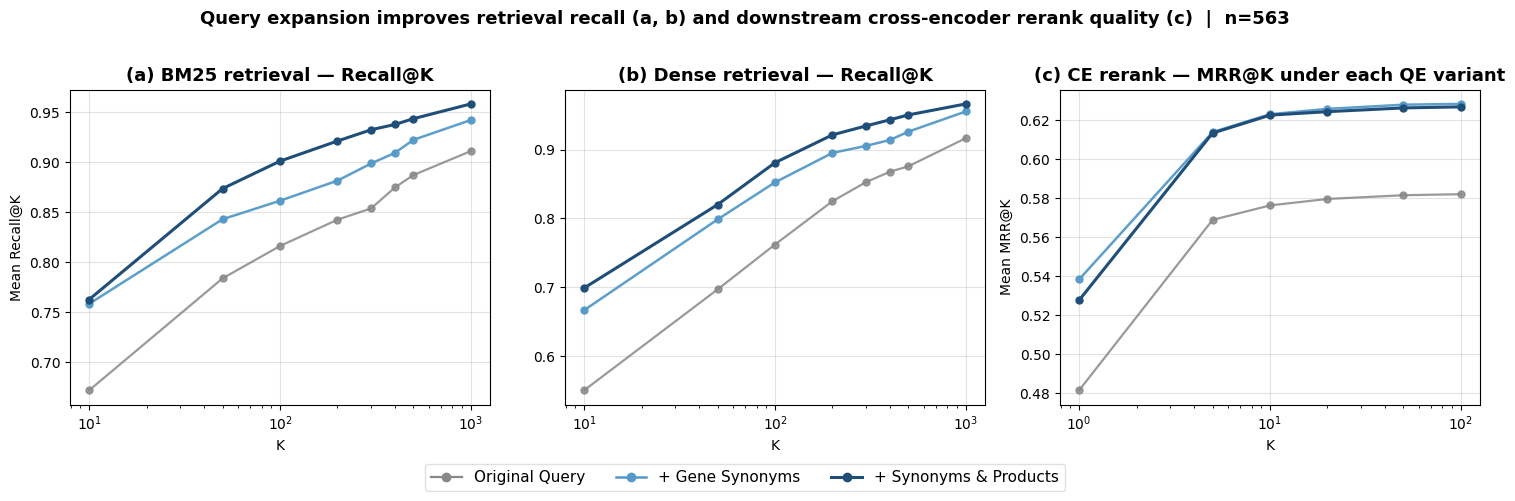

In [7]:
# Style: blue gradient for QE intensity, green for fusion punchline (matches Fig 1's "Fusion" color).
QE_STYLE = {
    "body":     {"color": "#888888", "label": "Original Query",        "lw": 1.6, "ls": "-",  "alpha": 0.85},
    "synonyms": {"color": "#5499c7", "label": "+ Gene Synonyms",       "lw": 1.8, "ls": "-",  "alpha": 0.95},
    "long":     {"color": "#1f4e79", "label": "+ Synonyms & Products", "lw": 2.2, "ls": "-",  "alpha": 1.00},
}
FUSION_STYLE = {
    "color": "#2ca02c", "label": "Retrieval Fusion (long QE) — no rerank",
    "lw": 2.6, "ls": "-", "alpha": 1.00,
}

n_q = len(fig2_gold)

fig, axes = plt.subplots(1, 3, figsize=(15, 4.7))
ax_a, ax_b, ax_c = axes


# Panel (a): BM25 Recall@K
for qf in ["body", "synonyms", "long"]:
    if qf not in bm25_recall:
        continue
    s = QE_STYLE[qf]
    ax_a.plot(fig2_ks_recall, bm25_recall[qf], marker="o", markersize=5,
              color=s["color"], linewidth=s["lw"], linestyle=s["ls"], alpha=s["alpha"])
ax_a.set_title(f"(a) BM25 retrieval — Recall@K", fontsize=13, fontweight="bold")
ax_a.set_xscale("log")
ax_a.set_xlabel("K")
ax_a.set_ylabel("Mean Recall@K")
ax_a.grid(True, axis="y", alpha=0.35)
ax_a.grid(True, axis="x", alpha=0.35)


# Panel (b): Dense Recall@K
for qf in ["body", "synonyms", "long"]:
    if qf not in dense_recall:
        continue
    s = QE_STYLE[qf]
    ax_b.plot(fig2_ks_recall, dense_recall[qf], marker="o", markersize=5,
              color=s["color"], linewidth=s["lw"], linestyle=s["ls"], alpha=s["alpha"])
ax_b.set_title(f"(b) Dense retrieval — Recall@K", fontsize=13, fontweight="bold")
ax_b.set_xscale("log")
ax_b.set_xlabel("K")
ax_b.set_ylabel("")
ax_b.grid(True, axis="y", alpha=0.35)
ax_b.grid(True, axis="x", alpha=0.35)


# Panel (c): CE rerank MRR@K under each QE variant. The retrieval-fusion line
# (no rerank) was deliberately dropped to keep the panel a clean QE-on-CE story;
# that comparison lives in the standalone supplement Fig S3 below.
for qf in ["body", "synonyms", "long"]:
    if qf not in mrr_curves:
        continue
    s = QE_STYLE[qf]
    ax_c.plot(fig2_ks_mrr, mrr_curves[qf], marker="o", markersize=5,
              color=s["color"], linewidth=s["lw"], linestyle=s["ls"], alpha=s["alpha"])

ax_c.set_title(f"(c) CE rerank — MRR@K under each QE variant", fontsize=13, fontweight="bold")
ax_c.set_xscale("log")
ax_c.set_xlabel("K")
ax_c.set_ylabel("Mean MRR@K")
ax_c.grid(True, axis="y", alpha=0.35)
ax_c.grid(True, axis="x", alpha=0.35)


# Shared legend
legend_handles = []
for qf in ["body", "synonyms", "long"]:
    s = QE_STYLE[qf]
    legend_handles.append(Line2D([0], [0], color=s["color"], marker="o",
                                 linewidth=s["lw"], label=s["label"]))
fig.legend(handles=legend_handles, loc="lower center", bbox_to_anchor=(0.5, -0.02),
           ncol=3, fontsize=11, frameon=True, edgecolor="0.85")

fig.suptitle(
    f"Query expansion improves retrieval recall (a, b) and downstream cross-encoder "
    f"rerank quality (c)  |  n={n_q}",
    fontsize=13, fontweight="bold", y=1.02,
)
plt.tight_layout()
fig.subplots_adjust(bottom=0.18)

fig2_path = fig2_out_dir / "fig2_candidate_qe_main.png"
fig.savefig(fig2_path, dpi=150, bbox_inches="tight")
print("Saved:", fig2_path)
plt.show()

## Numbers for §3.2 caption / text

In [8]:
def _fmt(v: float) -> str:
    return f"{v:.4f}"


print(f"=== Sample size: n={n_q} ===\n")
print("Panel (a) BM25 Recall@100 by QE:")
for qf in ["body", "synonyms", "long"]:
    if qf in bm25_recall:
        v = bm25_recall[qf][fig2_ks_recall.index(100)]
        print(f"  {qf:9s} {_fmt(v)}")
print()
print("Panel (b) Dense Recall@100 by QE:")
for qf in ["body", "synonyms", "long"]:
    if qf in dense_recall:
        v = dense_recall[qf][fig2_ks_recall.index(100)]
        print(f"  {qf:9s} {_fmt(v)}")
print()
print("Panel (c) MRR@10 by method:")
panel_c_order = ["body", "synonyms", "long", "fusion_long"]
for m in panel_c_order:
    if m in mrr_curves:
        v = mrr_curves[m][fig2_ks_mrr.index(10)]
        print(f"  {m:13s} {_fmt(v)}")

=== Sample size: n=563 ===

Panel (a) BM25 Recall@100 by QE:
  body      0.8163
  synonyms  0.8616
  long      0.9013

Panel (b) Dense Recall@100 by QE:
  body      0.7621
  synonyms  0.8524
  long      0.8810

Panel (c) MRR@10 by method:
  body          0.5761
  synonyms      0.6229
  long          0.6224
  fusion_long   0.6185


## Draft Results Text — §3.2 Query expansion delivers gains beyond the rerank ladder

*Numerical values populated from the cell above; n=563 (7d expanded-query
benchmark). Note that this benchmark differs from the n=1,656 default-query
goldset used in §3.1 — the figure caption should flag the change.*

> **3.2 Query expansion delivers gains beyond the rerank ladder.**
> Given the §3.1 finding that ranker upgrades plateau on dicty, we tested
> whether query-side modifications produce larger gains. We generated two
> expansion variants — gene synonyms only, and gene synonyms combined with
> gene-product names (long-form expansion) — and evaluated them on the
> n=563 expanded-query benchmark. Both BM25 (**Fig 2a**) and dense
> retrieval (**Fig 2b**) gain substantially in Recall@K: BM25 Recall@100
> rises from 0.816 (original query) to 0.901 (long-form), an +8.5 pp gain,
> and dense Recall@100 from 0.762 to 0.881 (+11.9 pp). At the rerank stage
> (**Fig 2c**), applying expansion to the cross-encoder rerank input
> improves MRR@10 from 0.576 to 0.622 — a +4.6 pp gain that is roughly
> 4× the entire stage-upgrade ladder reported in §3.1 (+1.2 pp). For
> consistency, on this benchmark a retrieval fusion of long-form queries
> (no rerank) achieves MRR@10 = 0.619 (**Fig S3**), reinforcing the §3.1
> finding that on dicty, query-side modifications carry more leverage than
> ranker-side ones.

**Key headline numbers** (for ablation tables / abstract):

| Method                                | MRR@10 | Recall@100 |
|---------------------------------------|--------|------------|
| BM25 (original query)                 | —      | 0.816      |
| BM25 (+ synonyms & products)          | —      | 0.901      |
| Dense (original query)                | —      | 0.762      |
| Dense (+ synonyms & products)         | —      | 0.881      |
| CE rerank on original query           | 0.576  | —          |
| CE rerank on synonyms expansion       | 0.623  | —          |
| CE rerank on long-form expansion      | 0.622  | —          |
| Retrieval Fusion (long QE, no rerank) | 0.619  | —          |

## Supplement Fig S3 — Retrieval-only QE fusion vs CE Rerank with QE

*Paper role:* supplement, consistency check supporting §3.2's claim that
query-side modifications carry more leverage than ranker-side ones. Shows
that a retrieval fusion of long-form QE variants (no reranker) lands at
essentially the same MRR@K as CE+long-QE — a separate piece of evidence
for §3.1's "ranker plateaus on dicty" finding, on the n=563 benchmark.

Saved: /Users/yun/develop/dictycite/output/workflow_baseline_full_sweep/workflow_query_field_sweep_no_rm3_7d/query_field_sweep/figures/fig_s3_retrieval_only_qe_vs_ce.png


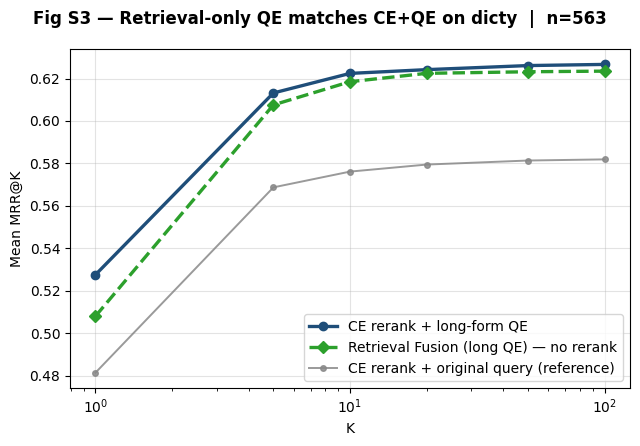

In [9]:
fig_s3, ax_s3 = plt.subplots(figsize=(6.5, 4.5))

# Two lines: CE+long (best CE+QE configuration) vs retrieval fusion (long QE, no rerank)
if "long" in mrr_curves:
    s = QE_STYLE["long"]
    ax_s3.plot(fig2_ks_mrr, mrr_curves["long"], marker="o", markersize=6,
               color=s["color"], linewidth=2.4, label="CE rerank + long-form QE")

if "fusion_long" in mrr_curves:
    ax_s3.plot(fig2_ks_mrr, mrr_curves["fusion_long"], marker="D", markersize=6,
               color="#2ca02c", linewidth=2.4, linestyle="--",
               label="Retrieval Fusion (long QE) — no rerank")

# Default reference (CE+body) for context
if "body" in mrr_curves:
    ax_s3.plot(fig2_ks_mrr, mrr_curves["body"], marker="o", markersize=4,
               color="#888888", linewidth=1.4, alpha=0.85,
               label="CE rerank + original query (reference)")

ax_s3.set_xscale("log")
ax_s3.set_xlabel("K")
ax_s3.set_ylabel("Mean MRR@K")
ax_s3.grid(True, axis="y", alpha=0.35)
ax_s3.grid(True, axis="x", alpha=0.35)
ax_s3.legend(fontsize=10, loc="lower right")
fig_s3.suptitle(
    f"Fig S3 — Retrieval-only QE matches CE+QE on dicty  |  n={n_q}",
    fontsize=12, fontweight="bold",
)
plt.tight_layout()
fig_s3_path = fig2_out_dir / "fig_s3_retrieval_only_qe_vs_ce.png"
fig_s3.savefig(fig_s3_path, dpi=150, bbox_inches="tight")
print("Saved:", fig_s3_path)
plt.show()